# Phase 1 - The Detective Work (Setup & Inspection)

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [55]:
df = pd.read_csv("data/customer_analytics.csv")
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


In [57]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


# Dataset Introduction

This dataset contains information about customer demographics and purchasing behavior collected from a retail business. The data is used to understand how different customer characteristics influence purchasing patterns.

Each row in the dataset represents one individual customer transaction or customer record. It provides details about the customer's personal and financial attributes along with their purchasing activity.

The columns describe different attributes such as:
- Age – The age of the customer.
- Gender – The gender category of the customer.
- Income – The annual income level of the customer.
- Purchase Amount – The total amount spent by the customer on purchases.

The objective of this analysis is to explore patterns in customer behavior, understand how individual variables are distributed, and identify relationships between demographic factors and purchasing activity using Exploratory Data Analysis (EDA). The insights obtained from this analysis can help businesses better understand their customers and make data-driven decisions.

# Phase 2 - The Cleanup (Data Preprocessing)

In [58]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [59]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].median())
df = df.drop_duplicates()
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

# Data Cleaning Decisions

- The 'Education' column contained 12 missing values. Since it is a categorical feature, missing values were replaced using the mode (most frequent category).
- The 'AnnualIncome' column also contained 12 missing values. These were filled using the median value because income data may contain extreme outliers.
- Five duplicate rows were identified and removed to prevent biased analysis results.

After preprocessing, the dataset became clean and suitable for exploratory analysis.

# Phase 3 - The Deep Dive (Univariate & Bivariate Analysis)

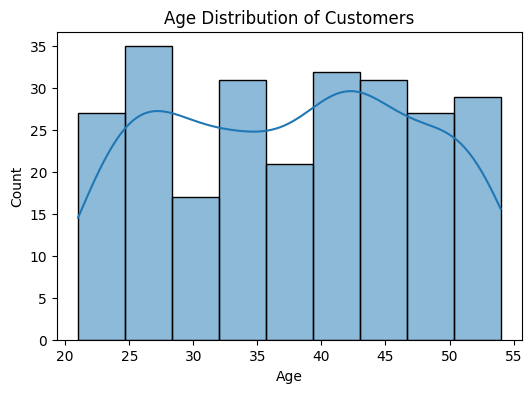

In [60]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution of Customers")
plt.show()

Most customers fall between ages 30 and 45, indicating that the business mainly attracts middle-aged individuals.

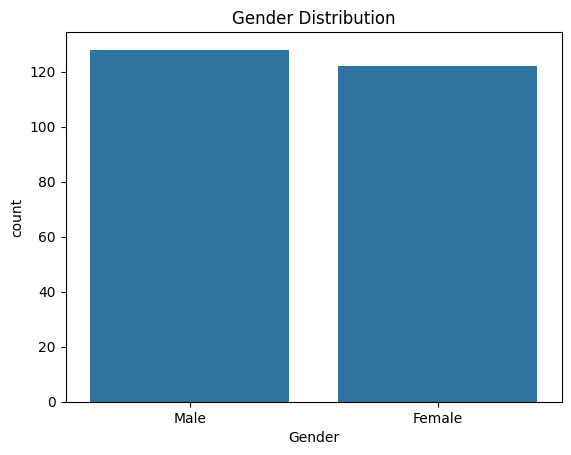

In [61]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

The dataset shows a relatively balanced gender distribution, allowing unbiased comparison between male and female customers.

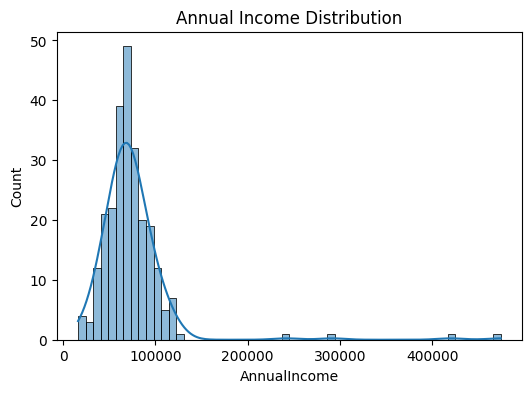

In [62]:
plt.figure(figsize=(6,4))
sns.histplot(df['AnnualIncome'], kde=True)
plt.title("Annual Income Distribution")
plt.show()

Income distribution is slightly right-skewed, meaning most customers fall into moderate income ranges while a few earn significantly higher incomes.

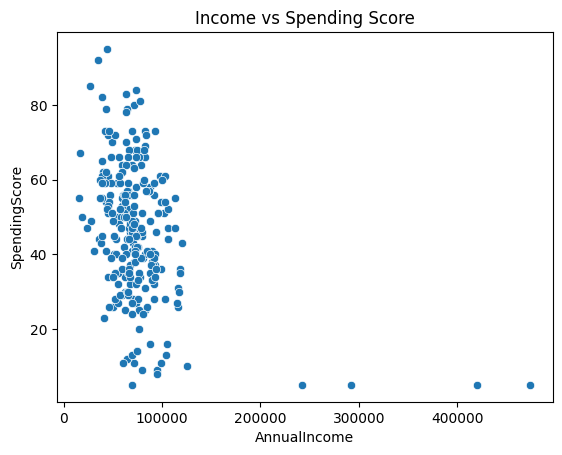

In [63]:
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df)
plt.title("Income vs Spending Score")
plt.show()

The scatter plot shows that higher income does not always result in higher spending, suggesting different customer spending behaviors across income groups.

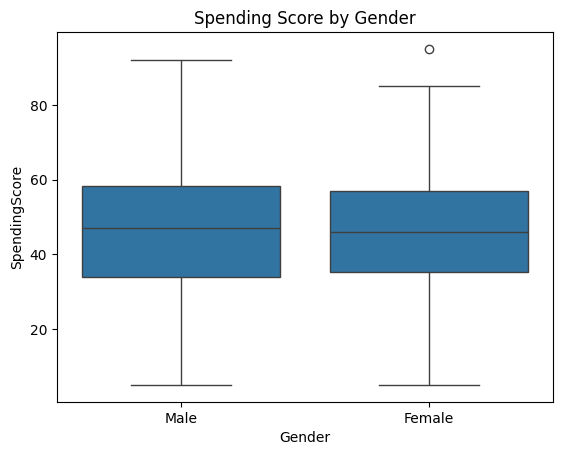

In [64]:
sns.boxplot(x='Gender', y='SpendingScore', data=df)
plt.title("Spending Score by Gender")
plt.show()

The boxplot reveals variation in spending behavior between genders, with both groups showing a wide range of spending scores.

# Phase 4 - The Big Picture (Multivariate & Storytelling)

In [65]:
corr = df.corr(numeric_only=True)
corr

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
CustomerID,1.000000,-0.038170,-0.039180,0.070869,-0.018877,-0.077040,-0.029642,0.023180,-0.034412
Age,-0.038170,1.000000,-0.051429,-0.006943,0.975242,0.103053,-0.033532,-0.051190,0.092891
AnnualIncome,-0.039180,-0.051429,1.000000,-0.384127,-0.054300,-0.036673,0.096734,-0.114378,-0.016602
SpendingScore,0.070869,-0.006943,-0.384127,1.000000,-0.017487,0.009792,-0.072441,0.057686,0.032737
YearsEmployed,-0.018877,0.975242,-0.054300,-0.017487,1.000000,0.073113,-0.052168,-0.050904,0.114464
PurchaseFrequency,-0.077040,0.103053,-0.036673,0.009792,0.073113,1.000000,-0.041362,0.084121,-0.068246
OnlineVisitsPerMonth,-0.029642,-0.033532,0.096734,-0.072441,-0.052168,-0.041362,1.000000,-0.071400,0.010528
ReturnedItems,0.023180,-0.051190,-0.114378,0.057686,-0.050904,0.084121,-0.071400,1.000000,0.016208
LastPurchaseAmount,-0.034412,0.092891,-0.016602,0.032737,0.114464,-0.068246,0.010528,0.016208,1.000000


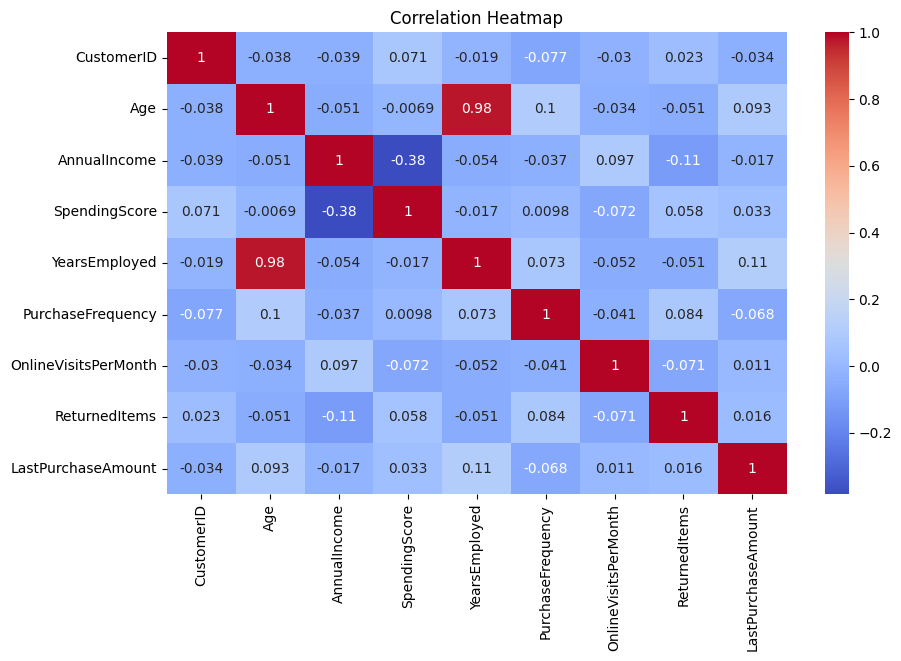

In [66]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between numerical variables. Strong correlations help identify factors that influence customer spending and purchasing behavior.

## Key Insights

1. Most customers belong to the middle-age group (30–45 years), indicating the primary target demographic.
2. Annual income does not strongly determine spending behavior, suggesting psychological or lifestyle factors influence purchases.
3. Purchase-related variables such as spending score and purchase frequency show moderate relationships, indicating consistent buying patterns among active customers.

Overall, the dataset provides valuable insights into customer demographics and purchasing behavior, which can help businesses improve marketing strategies and customer segmentation.